# Regressão

## Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Gym Exercise

In [ ]:
path = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Regressao/Regressao-main/Datasets/gym_members_exercise_tracking.csv"

In [5]:
path

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Regressao/Regressao-main/Datasets/gym_members_exercise_tracking.csv'

In [6]:
df_gym = pd.read_csv(path + "/gym_members_exercise_tracking.csv")

In [7]:
df_gym.shape

(973, 15)

In [8]:
df_gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


<Axes: xlabel='Session_Duration (hours)', ylabel='Calories_Burned'>

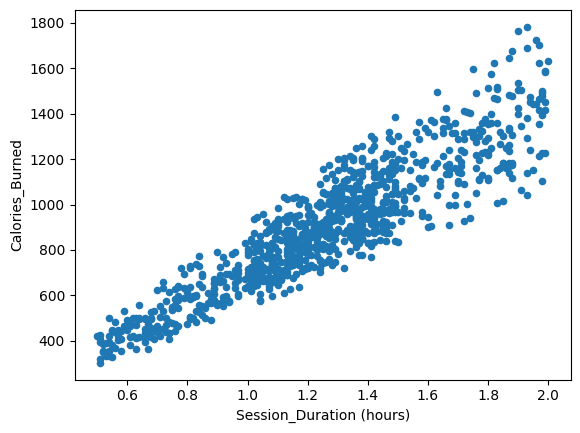

In [9]:
df_gym.plot(x="Session_Duration (hours)", y="Calories_Burned", kind="scatter")

## Separando Atributos e Target

In [10]:
X = df_gym[["Session_Duration (hours)"]]
y = df_gym[["Calories_Burned"]]

## Criando uma Regressão Linear Simples

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
pred = model.predict(X)

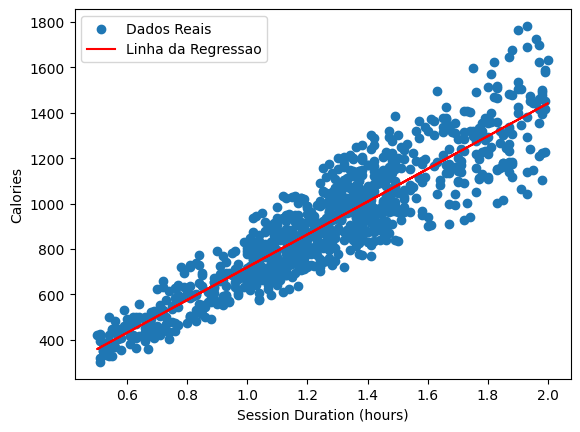

In [14]:
plt.scatter(x=X["Session_Duration (hours)"], y=y, label="Dados Reais")
plt.plot(X["Session_Duration (hours)"], pred, label="Linha da Regressao", color="red")

plt.ylabel("Calories")
plt.xlabel("Session Duration (hours)")
plt.legend()
plt.show()

In [15]:
residuals = y - pred

In [16]:
residuals

,Calories_Burned
0,94.628092
1,-53.875362
2,-122.736019
3,107.592709
4,95.503409
...,...
968,232.242414
969,265.381757
970,-311.025489
971,90.481841


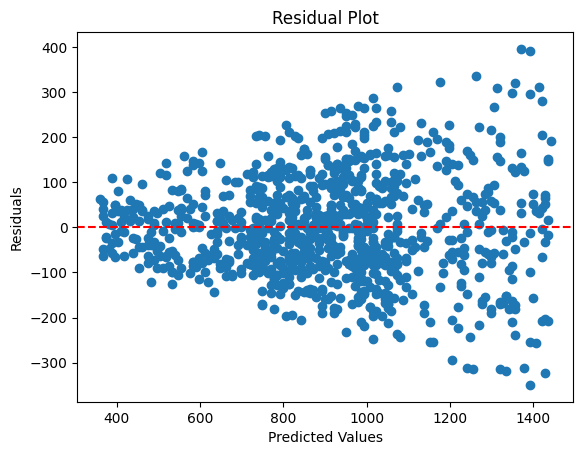

In [17]:
plt.scatter(pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Text(0.5, 1.0, 'Pred x Target')

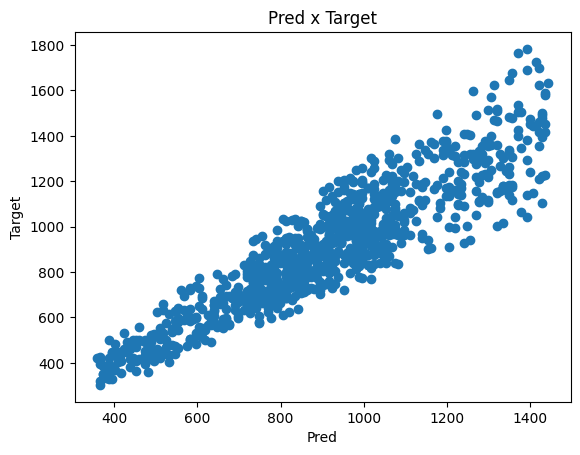

In [18]:
plt.scatter(pred, y)
plt.xlabel("Pred")
plt.ylabel("Target")
plt.title("Pred x Target")

## Separando os dados em Treino e Teste

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X = df_gym.drop("Calories_Burned", axis=1)
y = df_gym["Calories_Burned"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [22]:
X_train.shape

(778, 14)

In [23]:
X_test.shape

(195, 14)

In [24]:
X_train.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
967,20,Male,55.0,1.60,172,168,67,1.12,Yoga,24.0,3.2,4,2,21.48
365,39,Female,60.6,1.65,162,167,63,0.92,HIIT,27.6,1.7,3,1,22.26
559,54,Female,75.6,1.72,194,154,60,0.97,Cardio,26.4,1.9,3,1,25.55
33,24,Female,58.9,1.51,187,157,68,1.04,Cardio,31.7,2.5,2,1,25.83
31,20,Female,65.4,1.52,185,127,50,1.03,Yoga,28.0,2.2,4,2,28.31


## Tratando atributos categóricos

In [25]:
X_train["Workout_Type"].value_counts()

Workout_Type
Strength    211
Cardio      209
HIIT        179
Yoga        179
Name: count, dtype: int64

In [26]:
from sklearn.preprocessing import OneHotEncoder

In [27]:
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
encoder.fit(X_train[["Workout_Type", "Gender"]])

X_train_categorical_columns = encoder.transform(X_train[["Workout_Type", "Gender"]])
X_test_categorical_columns = encoder.transform(X_test[["Workout_Type", "Gender"]])

In [28]:
X_train = pd.concat([X_train.drop(["Workout_Type", "Gender"], axis=1), X_train_categorical_columns], axis=1)

In [29]:
X_test = pd.concat([X_test.drop(["Workout_Type", "Gender"], axis=1), X_test_categorical_columns], axis=1)

### Trinando e realizando Predict

In [30]:
from sklearn.metrics import mean_absolute_error

In [31]:
model = LinearRegression()
model.fit(X_train[["Session_Duration (hours)"]], y_train)

y_pred = model.predict(X_test[["Session_Duration (hours)"]])
mae = mean_absolute_error(y_test, y_pred)
mae

95.03480033445553

## Avaliando as predições

In [32]:
residuals = y_test - y_pred

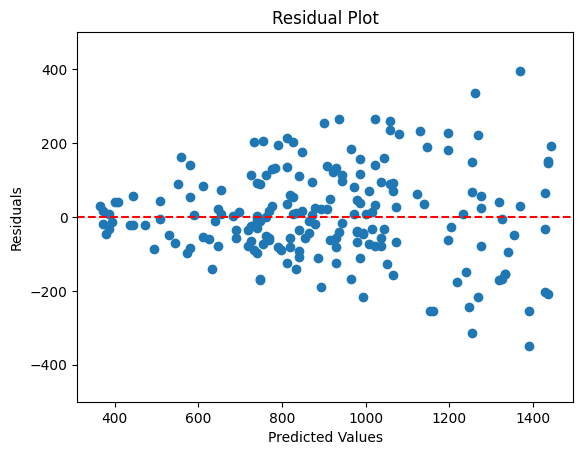

In [33]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.ylim((-500, 500))
plt.show()

## Regressão Linear Múltipla

In [34]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mae

30.270139845320745

In [35]:
residuals = y_test - y_pred

In [36]:
residuals.abs().mean()

np.float64(30.270139845320745)

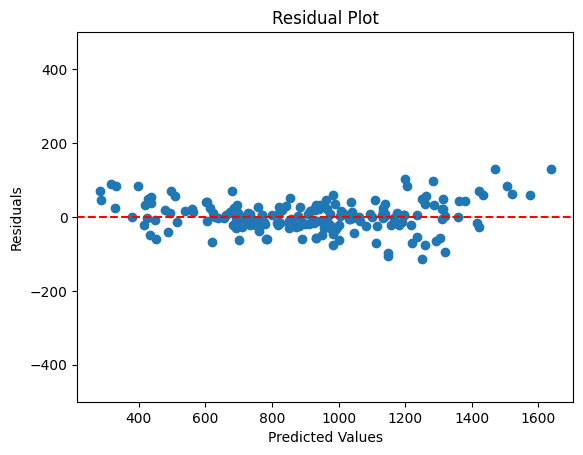

In [37]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.ylim((-500, 500))
plt.show()

## Interpretando os Coeficientes da Regressão Linear

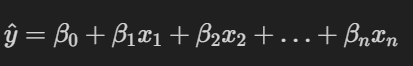

In [38]:
model.intercept_

np.float64(-983.6778704343365)

In [39]:
model.coef_

array([-3.31556080e+00, -1.00598336e+00,  1.08168013e+02,  1.08805915e-01,
        6.15788095e+00,  6.03315684e-01,  7.12813300e+02, -6.43730698e-01,
       -3.53909166e+00,  3.95769050e+00, -3.67455298e+00,  3.36018705e+00,
        3.95997991e+00, -2.67674260e-01,  6.95260162e-01, -4.38756581e+00,
       -4.12986606e+01,  4.12986606e+01])

In [40]:
len(model.coef_)

18

In [41]:
X_test.iloc[0].values

array([ 34.  ,  71.9 ,   1.64, 170.  , 134.  ,  67.  ,   1.26,  21.3 ,
         2.1 ,   4.  ,   2.  ,  26.73,   1.  ,   0.  ,   0.  ,   0.  ,
         0.  ,   1.  ])

In [42]:
x = X_test.iloc[0].values

In [43]:
sum(model.coef_ * x) + model.intercept_

np.float64(913.2929019751896)

In [44]:
y_pred[0]

np.float64(913.2929019751898)

In [45]:
df_coef = pd.DataFrame({
    "Features": X_train.columns,
    "Coeficientes": model.coef_
})
df_coef

,Features,Coeficientes
0,Age,-3.315561
1,Weight (kg),-1.005983
2,Height (m),108.168013
3,Max_BPM,0.108806
4,Avg_BPM,6.157881
5,Resting_BPM,0.603316
6,Session_Duration (hours),712.813300
7,Fat_Percentage,-0.643731
8,Water_Intake (liters),-3.539092
9,Workout_Frequency (days/week),3.957690


In [46]:
df_coef["Coeficientes_Absoluto"] = df_coef["Coeficientes"].abs()

<Axes: ylabel='Features'>

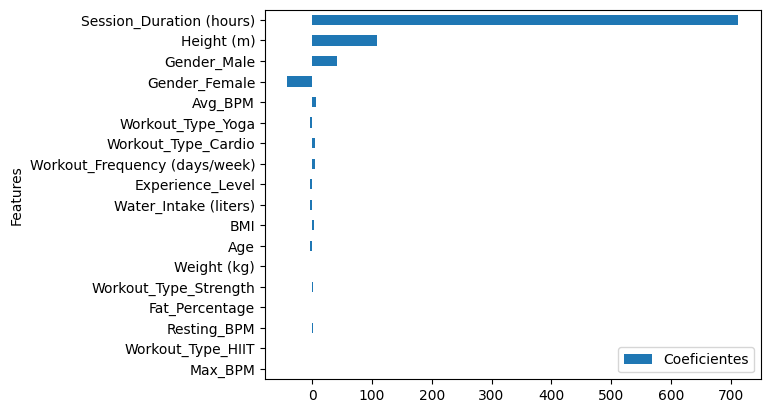

In [47]:
df_coef.sort_values("Coeficientes_Absoluto", ascending=True).plot(kind="barh", x="Features", y="Coeficientes")

<Axes: title={'center': 'Distribuicao dos Residuais'}, ylabel='Frequency'>

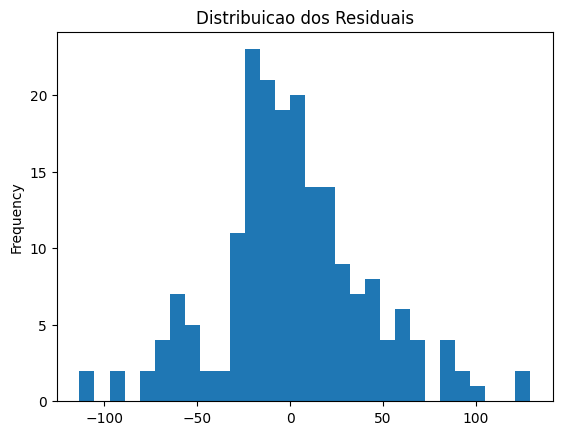

In [48]:
residuals.plot(kind="hist", bins=30, title="Distribuicao dos Residuais")

## Analisando os dados

In [49]:
df_corr = X_train.corr()

In [50]:
df_corr

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Gender_Female,Gender_Male
Age,1.000000,-0.067671,-0.016373,-0.021903,0.080135,-0.008126,-0.011484,0.008664,0.034919,0.030417,-0.008071,-0.053464,-0.040301,0.003777,0.019944,0.017598,-0.006300,0.006300
Weight (kg),-0.067671,1.000000,0.372351,0.049328,-0.011073,-0.013469,-0.011101,-0.234515,0.408174,0.005948,0.015118,0.849798,0.026978,0.039012,-0.046924,-0.017857,-0.573180,0.573180
Height (m),-0.016373,0.372351,1.000000,-0.057417,-0.017122,-0.000547,-0.009226,-0.238102,0.391995,0.001349,0.004269,-0.157753,-0.019376,-0.013922,-0.025376,0.061132,-0.586690,0.586690
Max_BPM,-0.021903,0.049328,-0.057417,1.000000,-0.042396,0.027311,0.030093,-0.013544,0.030548,-0.021016,0.000106,0.083389,0.008156,0.012005,-0.041880,0.023644,0.011065,-0.011065
Avg_BPM,0.080135,-0.011073,-0.017122,-0.042396,1.000000,0.070027,0.028216,-0.020048,-0.003184,-0.001472,0.009077,-0.002203,0.000443,-0.005342,0.009270,-0.004917,-0.000266,0.000266
Resting_BPM,-0.008126,-0.013469,-0.000547,0.027311,0.070027,1.000000,0.023454,-0.031448,0.053768,0.020149,0.031435,-0.013961,-0.050151,0.057657,0.031273,-0.037874,-0.021415,0.021415
Session_Duration (hours),-0.011484,-0.011101,-0.009226,0.030093,0.028216,0.023454,1.000000,-0.578470,0.254766,0.639245,0.763745,-0.003247,-0.051015,0.048021,0.014462,-0.009571,0.028182,-0.028182
Fat_Percentage,0.008664,-0.234515,-0.238102,-0.013544,-0.020048,-0.031448,-0.578470,1.000000,-0.586133,-0.536769,-0.652545,-0.125843,0.043005,-0.061803,0.052382,-0.038819,0.406813,-0.406813
Water_Intake (liters),0.034919,0.408174,0.391995,0.030548,-0.003184,0.053768,0.254766,-0.586133,1.000000,0.233791,0.289955,0.229339,-0.003511,0.058777,-0.042847,-0.009819,-0.673774,0.673774
Workout_Frequency (days/week),0.030417,0.005948,0.001349,-0.021016,-0.001472,0.020149,0.639245,-0.536769,0.233791,1.000000,0.831661,0.013200,-0.059923,0.014981,0.037810,0.008187,0.002357,-0.002357


<Axes: >

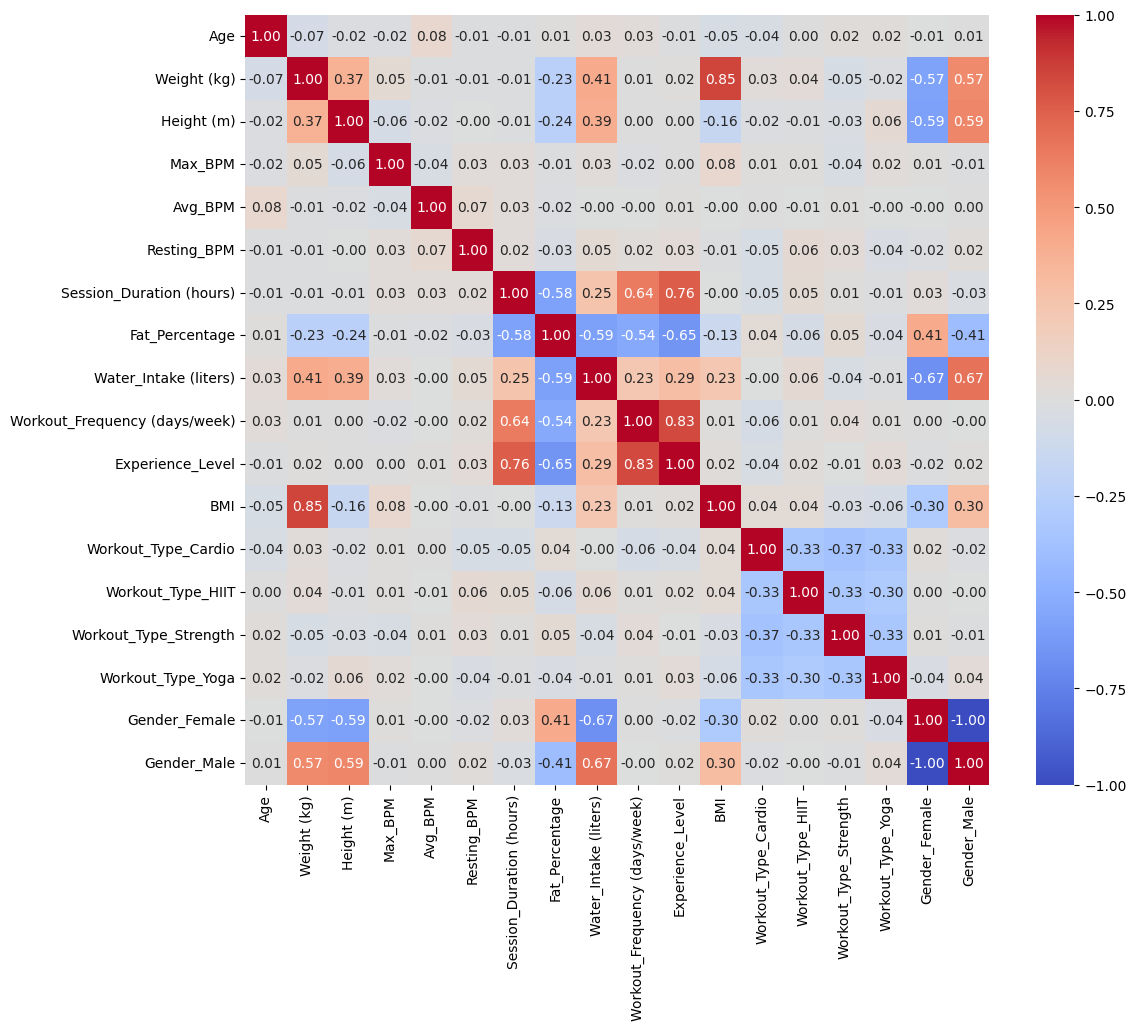

In [51]:
plt.figure(figsize=(12,10))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm")

## Métricas de Avaliação

### Mean Absolute Error (MAE)

In [52]:
residuals

199    15.707098
538   -15.980086
174   -31.023330
464    45.665579
66     82.571839
         ...    
578    18.726385
327   -29.474578
878    -4.639996
849   -67.042218
801    69.336017
Name: Calories_Burned, Length: 195, dtype: float64

In [53]:
residuals.abs()

199    15.707098
538    15.980086
174    31.023330
464    45.665579
66     82.571839
         ...    
578    18.726385
327    29.474578
878     4.639996
849    67.042218
801    69.336017
Name: Calories_Burned, Length: 195, dtype: float64

In [54]:
residuals.abs().mean()

np.float64(30.270139845320745)

In [55]:
from sklearn.metrics import mean_absolute_error

In [56]:
mean_absolute_error(y_test, y_pred)

30.270139845320745

### Mean Squared Error (MSE) e Root Mean Squared Error (RMSE)

In [57]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [58]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

In [59]:
print("MSE", mse)
print("RMSE", rmse)

MSE 1646.1760145970516
RMSE 40.57309471308606


In [60]:
np.sqrt(mse)

np.float64(40.57309471308606)

In [61]:
(residuals ** 2).mean()

np.float64(1646.1760145970516)

### Mean Absolute Percentage Error (MAPE)

In [62]:
from sklearn.metrics import mean_absolute_percentage_error

In [63]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE", mape)

MAPE 0.03685299217151924


In [64]:
mape * 100

3.6852992171519237

### R2 (R-Squared)

In [65]:
from sklearn.metrics import r2_score

In [66]:
r2 = r2_score(y_test, y_pred)
print("R2", r2)

R2 0.9802675995368527
